# Allen recovery gap: baseline extrapolation audit

## tl;dr
- positive: old RMS 204.59 uV; linear RMS 231.71 uV; ratio 1.13. Lower linear RMS in 9/20 sweeps.
- negative: old RMS 103.04 uV; linear RMS 163.21 uV; ratio 1.58. Lower linear RMS in 2/20 sweeps.

These are observed contrast magnitudes, not errors against a known response.

## Context & Methods
One experiment (1574292898.139), sweeps 37–56, one stimulated source and two targets.
The previous operator is post[2,8) ms minus pre[-8,-3) ms, relative to the detected
source spike. The candidate extrapolates an ordinary least-squares line fitted
only to the pre window. All 12 actual pulses and both targets are retained.

### Key Assumptions
Five pseudo events occur 20, 40, 60, 80 and 100 ms after the eighth detected spike.
Their enclosing windows precede pulse 9 and have zero stored source command.
Target commands are also verified from offline NWB blocks. Holding settings,
spontaneous input and residual responses remain: zero is not a known biological
response. **RMS measures contrast magnitude, not prediction error.**
Sweeps are repeated observations of these same cells, not independent animals.
Early/late halves are descriptive checks of already inspected data.

## Data


In [1]:
import hashlib, json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

root = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p/'verify/Q-NPF-04/allen_synphys/recovery_baseline_extrapolation_result.json').exists())
folder = root/'verify/Q-NPF-04/allen_synphys'
path = folder/'recovery_baseline_extrapolation_result.json'
result = json.loads(path.read_text(encoding='utf-8'))
def digest(p):
    with Path(p).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()
assert digest(folder/'recovery_baseline_extrapolation.py') == result['code_sha256']
for key, name in dict(train='recovery_train_responses_result.json',
                     targets='ic_full_recording_qc_result.json',
                     inventory='ic_extended_inventory_result.json').items():
    assert digest(folder/name) == result['source_sha256'][key]
for asset in result['input_assets']:
    assert digest(root/asset['path']) == asset['sha256']
rows = result['records']
assert len(rows) == 680 and len(result['input_assets']) == 60
assert len(result['command_verification']['checks']) == 40
assert not result['command_verification']['missing_blocks']
print('Result SHA256:', digest(path))
print('Verified: 60 input archives, 480 actual responses, 200 gap contrasts, 40 target commands.')
print('Maximum old-response mismatch (uV):', result['old_response_reproduction']['max_abs_error_uV'])


Result SHA256: b67236c43b795e0173530d8a9ee97380210c5499cc97c76e1397bcb572b3e13e
Verified: 60 input archives, 480 actual responses, 200 gap contrasts, 40 target commands.
Maximum old-response mismatch (uV): 4.2170711367361946e-11


## Results

### Contrast magnitude in the recovery gap
Each target/half summary retains every selected sweep and all five pseudo events.
A reduction alone would not establish isolation of the true evoked response.


In [2]:
print(f"{'Target':<10} {'Sweeps':<10} {'Old RMS/uV':>12} {'Linear RMS/uV':>15} {'Ratio':>8} {'Lower/sweeps':>14}")
for summary in result['summary']:
    if summary['kind'] != 'gap_control':
        continue
    old = np.array([r['old_uV'] for r in rows if r['kind']=='gap_control' and r['target']==summary['target']
                    and (summary['half']=='all' or (r['sweep']<=46)==(summary['half']=='early'))])
    assert np.sqrt(np.mean(old**2)) == summary['old']['rms_uV']
    print(f"{summary['target']:<10} {summary['half']:<10} {summary['old']['rms_uV']:12.3f} "
          f"{summary['linear']['rms_uV']:15.3f} {summary['rms_ratio']:8.3f} "
          f"{summary['sweeps_lower_linear_rms']:>7}/{summary['sweeps']:<6}")
noise = result['ideal_noise_geometry']
print('Ideal iid-window noise SD multiplier:', noise['sd_ratio'])
print(noise['assumption'])


Target     Sweeps       Old RMS/uV   Linear RMS/uV    Ratio   Lower/sweeps
positive   all             204.592         231.707    1.133       9/20    
positive   early           171.729         258.896    1.508       3/10    
positive   late            232.862         200.871    0.863       6/10    
negative   all             103.044         163.208    1.584       2/20    
negative   early            91.053         170.569    1.873       1/10    
negative   late            113.778         155.498    1.367       1/10    
Ideal iid-window noise SD multiplier: 5.464940073572402
Independent equal-variance resampled window values; ignores voltage autocorrelation and interpolation covariance. This is operator geometry, not measured physiological noise.


### Actual pulse profiles and paired sweep controls
Top: actual contrasts, mean across 20 sweeps; shading is between-sweep SD, not a
confidence interval. Bottom: one point per sweep, RMS over its five gap windows.
Points above the identity line have larger magnitude after linear extrapolation.
The database labels “positive” and “negative” do not describe voltage signs.


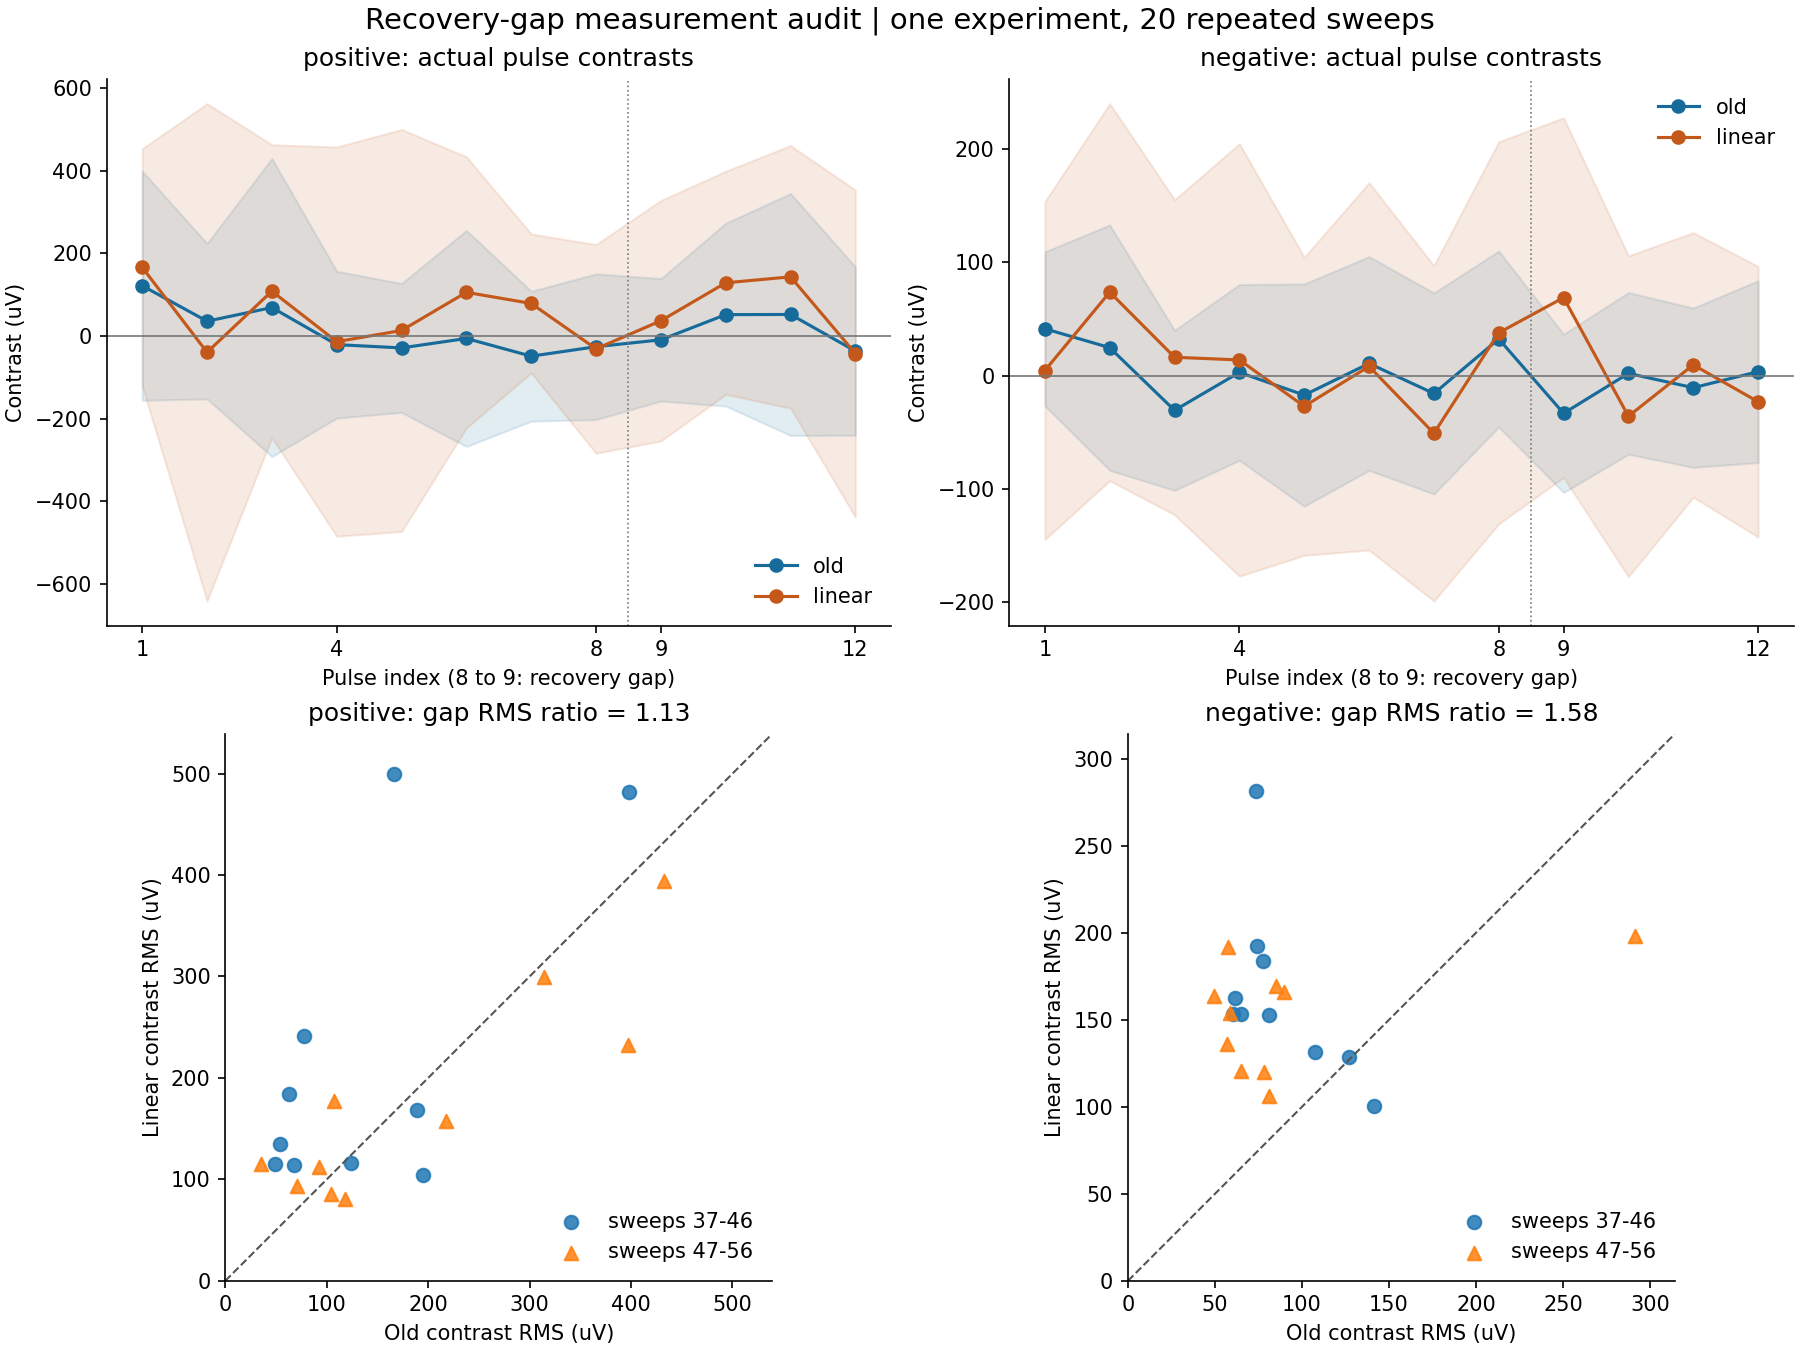

In [3]:
plt.rcParams.update({'font.size':10, 'axes.spines.top':False, 'axes.spines.right':False})
fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout='constrained')
colors = {'old':'#176B9B', 'linear':'#C4581B'}
for col, target in enumerate(('positive', 'negative')):
    ax = axes[0,col]
    for method in ('old', 'linear'):
        values = np.array([[next(r[method+'_uV'] for r in rows
                            if r['kind']=='actual' and r['target']==target
                            and r['sweep']==sw and r['pulse']==pulse)
                            for pulse in range(1,13)] for sw in range(37,57)])
        mean, sd = values.mean(axis=0), values.std(axis=0, ddof=1)
        x = np.arange(1,13)
        ax.plot(x, mean, 'o-', color=colors[method], label=method)
        ax.fill_between(x, mean-sd, mean+sd, color=colors[method], alpha=.12)
    ax.axhline(0, color='#777777', linewidth=.8)
    ax.axvline(8.5, color='#777777', linewidth=.8, linestyle=':')
    ax.set(title=f'{target}: actual pulse contrasts', xlabel='Pulse index (8 to 9: recovery gap)', ylabel='Contrast (uV)')
    ax.set_xticks([1,4,8,9,12])
    ax.legend(frameon=False)
    ax = axes[1,col]
    summary = next(s for s in result['summary'] if s['target']==target and s['kind']=='gap_control' and s['half']=='all')
    pairs = summary['per_sweep']
    x = np.array([p['old_rms_uV'] for p in pairs])
    y = np.array([p['linear_rms_uV'] for p in pairs])
    for label, mask, marker in [('sweeps 37-46',np.arange(20)<10,'o'), ('sweeps 47-56',np.arange(20)>=10,'^')]:
        ax.scatter(x[mask],y[mask],label=label,marker=marker,s=42,alpha=.85)
    limit = max(x.max(),y.max())*1.08
    ax.plot([0,limit],[0,limit], '--',color='#555555',linewidth=1)
    ax.set(xlim=(0,limit), ylim=(0,limit), aspect='equal',
           title=f"{target}: gap RMS ratio = {summary['rms_ratio']:.2f}",
           xlabel='Old contrast RMS (uV)', ylabel='Linear contrast RMS (uV)')
    ax.legend(frameon=False,loc='lower right')
fig.suptitle('Recovery-gap measurement audit | one experiment, 20 repeated sweeps',fontsize=14)
figure = folder/'figures/recovery_baseline_extrapolation.png'
figure.parent.mkdir(exist_ok=True)
fig.savefig(figure,dpi=150)
display(Image(filename=str(figure)))
plt.close(fig)


## Takeaways
The output is a measurement diagnostic, not an estimate of synaptic efficacy or
learning. Affine extrapolation removes an affine baseline exactly but need not
remove a curved membrane tail and can amplify noise. Keep the original responses.

A fixed passive filter already contains an input history: \(V=K*I\).
In frequency coordinates, \(\widehat V=H(\omega)\widehat I\); a pure delay contributes
\(e^{-i\omega\tau_d}\), while a passive RC membrane contributes
\(R/(1+i\omega RC)\). Thus phase shifts and residual tails can arise with fixed
parameters. This candidate correction does not fit that physical filter.
[Primary textbook derivation](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html).

Source-injected current is not target synaptic current. A future filter comparison
must model the measured input/output chain, preserve timing, and compare held-out
responses before attributing additional history dependence to plasticity.
